# 02 Learning Models

Goal:

For each selected player:

1. plot trajectory
2. fit Power Law
3. fit Exponential
4. compare AIC/BIC
5. save results

Outputs:

- model_comparison.csv
- fit_parameters.csv
- residuals.csv
- model_summary.csv
- model_ranking.csv
- example_player_fit.png
- example_player_residuals.png

This notebook uses the sequential attempt index from player_trajectories.csv so the x-axis matches learning-curve modeling.
Model comparison is based on AIC/BIC; lower values are better.
Delta AIC is interpreted by absolute magnitude so the final report can distinguish weak vs strong evidence.

In [ ]:
from pathlib import Path
import sys
import importlib

import pandas as pd
from IPython.display import display

import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data" / "processed").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data_loading import processed_data_dir, results_data_dir
from src.learning_models import (
    power_law,
    exponential,
    fit_power_law,
    fit_exponential,
    residuals,
    evaluate_model,
)
import src.visualization as visualization
importlib.reload(visualization)
from src.visualization import plot_learning_curve, plot_model_fits, plot_residual_series

experiment_name = "case_study_333_10players"
processed_dir = processed_data_dir(ROOT, experiment_name=experiment_name)
results_dir = results_data_dir(ROOT, experiment_name=experiment_name)
processed_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
selected_players = pd.read_csv(processed_dir / "selected_players.csv")
player_trajectories = pd.read_csv(processed_dir / "player_trajectories.csv", parse_dates=["competition_date"])

display(selected_players)
display(player_trajectories.head())
print(f"Selected players: {len(selected_players)}")
print(f"Trajectory rows: {len(player_trajectories)}")
print(f"Processed dir: {processed_dir}")
print(f"Results dir: {results_dir}")

,WCA ID,Name,#Competitions,#Results,First Year,Last Year,Span
0,2011EDUA01,Eduard Esteban García Domínguez,324,860,2011,2026,15
1,2010ROSE03,Dennis Rosero,312,759,2010,2026,16
2,2009PROV01,Matteo Provasi,281,750,2009,2026,17
3,2013WALL03,Daniel Wallin,296,711,2013,2026,13
4,2012MAHV01,Paul Mahvi,242,702,2012,2026,14
5,2009LIUE01,Evan Liu,264,700,2009,2026,17
6,2010HULL01,Katie Hull,236,684,2010,2026,16
7,2014ZAKR01,Karol Zakrzewski,231,650,2014,2026,12
8,2013ROGA02,Przemysław Rogalski,299,626,2013,2026,13
9,2012PARK03,Max Park,203,618,2012,2026,14


,person_id,person_name,competition_date,average_seconds,seq_index
0,2009LIUE01,Evan Liu,2009-05-30,44.77,1
1,2009LIUE01,Evan Liu,2009-08-14,33.30,2
2,2009LIUE01,Evan Liu,2010-01-30,20.28,3
3,2009LIUE01,Evan Liu,2010-01-30,21.71,4
4,2009LIUE01,Evan Liu,2010-04-18,20.91,5


Selected players: 10
Trajectory rows: 7056


## Example Player

Inspect one selected player first, then fit the models for all selected players.

Example player: Eduard Esteban García Domínguez (2011EDUA01)
Observations: 860


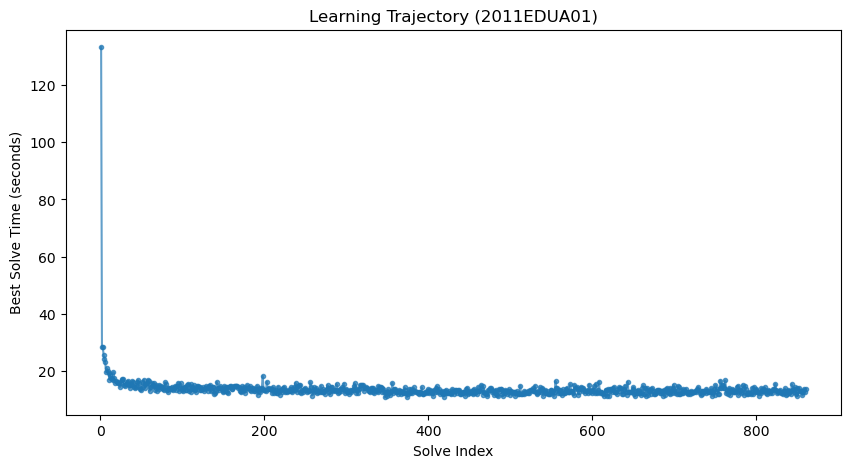

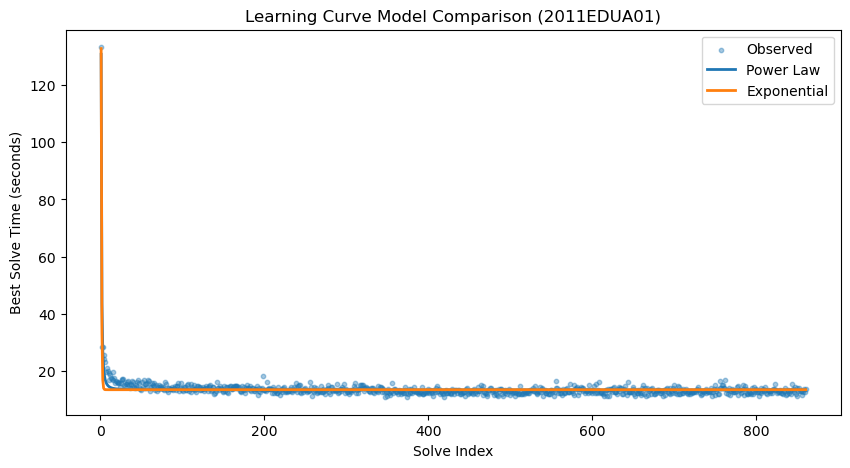

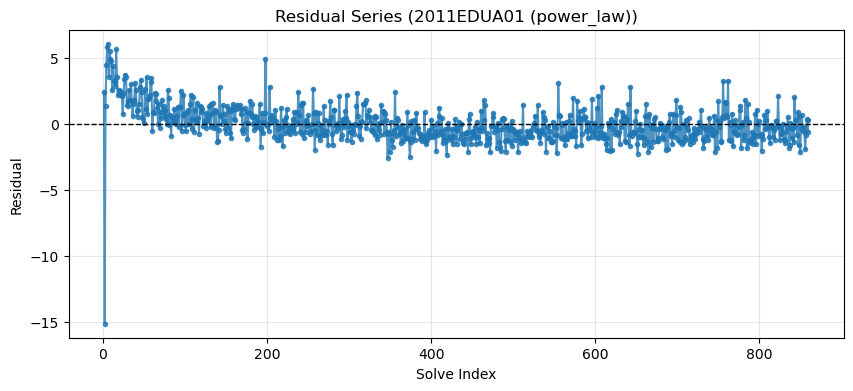

Example winner: power_law
Saved fit figure to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\example_player_fit.png
Saved residual figure to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\example_player_residuals.png
Power law metrics: {'rss': 1604.8257381581093, 'r2': 0.9034085219892318, 'aic': 542.5007368164354, 'bic': 556.7715339841781}
Exponential metrics: {'rss': 1930.0261365801953, 'r2': 0.883835314514798, 'aic': 701.1865339531236, 'bic': 715.4573311208662}


In [11]:
example_player = selected_players.iloc[0]
example_player_id = example_player["WCA ID"]
example_player_name = example_player["Name"]

example = player_trajectories.loc[
    player_trajectories["person_id"] == example_player_id,
    ["person_id", "person_name", "competition_date", "average_seconds", "seq_index"],
].copy()
example = example.sort_values("seq_index").reset_index(drop=True)

x = example["seq_index"].to_numpy(dtype=float)
y = example["average_seconds"].to_numpy(dtype=float)

print(f"Example player: {example_player_name} ({example_player_id})")
print(f"Observations: {len(example)}")

fig, ax = plot_learning_curve(x, y, player_id=example_player_id)
plt.show()

power_params, power_covariance = fit_power_law(x, y)
exp_params, exp_covariance = fit_exponential(x, y)

power_pred = power_law(x, *power_params) if power_params is not None else None
exp_pred = exponential(x, *exp_params) if exp_params is not None else None

example_power_metrics = evaluate_model(y, power_pred, n_params=3) if power_pred is not None else None
example_exp_metrics = evaluate_model(y, exp_pred, n_params=3) if exp_pred is not None else None

if example_power_metrics is None and example_exp_metrics is None:
    raise RuntimeError("Both models failed for the example player.")

if example_power_metrics is None:
    example_winner = "exponential"
    example_pred = exp_pred
    example_residual_values = residuals(y, exp_pred)
elif example_exp_metrics is None:
    example_winner = "power_law"
    example_pred = power_pred
    example_residual_values = residuals(y, power_pred)
elif example_power_metrics["aic"] <= example_exp_metrics["aic"]:
    example_winner = "power_law"
    example_pred = power_pred
    example_residual_values = residuals(y, power_pred)
else:
    example_winner = "exponential"
    example_pred = exp_pred
    example_residual_values = residuals(y, exp_pred)

fit_path = results_dir / "example_player_fit.png"
residual_path = results_dir / "example_player_residuals.png"

fig, ax = plot_model_fits(x, y, power_pred, exp_pred, player_id=example_player_id)
fig.savefig(fit_path, dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plot_residual_series(x, example_residual_values, player_id=f"{example_player_id} ({example_winner})")
fig.savefig(residual_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Example winner: {example_winner}")
print(f"Saved fit figure to: {fit_path}")
print(f"Saved residual figure to: {residual_path}")
print("Power law metrics:", example_power_metrics)
print("Exponential metrics:", example_exp_metrics)

## Model Fitting

Fit Power Law and Exponential models for all selected players, then compare AIC and BIC.

The resulting tables are saved as model_comparison.csv, fit_parameters.csv, and residuals.csv.

In [8]:
def interpret_delta_aic(delta_aic):
    if pd.isna(delta_aic):
        return None
    magnitude = abs(delta_aic)
    if magnitude < 2:
        strength = "weak"
    elif magnitude < 6:
        strength = "moderate"
    elif magnitude < 10:
        strength = "strong"
    else:
        strength = "very strong"
    direction = "power law" if delta_aic > 0 else "exponential" if delta_aic < 0 else "tie"
    return f"{strength} support for {direction}"

selected_ids = selected_players["WCA ID"].tolist()
analysis_rows = []
parameter_rows = []
residual_rows = []
failed_players = []

selected_trajectories = player_trajectories.loc[
    player_trajectories["person_id"].isin(selected_ids),
].copy()
selected_trajectories = selected_trajectories.sort_values(["person_id", "seq_index"]).reset_index(drop=True)

for person_id, group in selected_trajectories.groupby("person_id", sort=False):
    group = group.sort_values("seq_index").reset_index(drop=True)
    player_name = group["person_name"].iloc[0]
    x = group["seq_index"].to_numpy(dtype=float)
    y = group["average_seconds"].to_numpy(dtype=float)

    power_params, power_covariance = fit_power_law(x, y)
    exp_params, exp_covariance = fit_exponential(x, y)

    power_pred = power_law(x, *power_params) if power_params is not None else None
    exp_pred = exponential(x, *exp_params) if exp_params is not None else None

    power_metrics = evaluate_model(y, power_pred, n_params=3) if power_pred is not None else None
    exp_metrics = evaluate_model(y, exp_pred, n_params=3) if exp_pred is not None else None

    if power_params is not None:
        parameter_rows.append({
            "person_id": person_id,
            "person_name": player_name,
            "model": "power_law",
            "a": power_params[0],
            "b": power_params[1],
            "c": power_params[2],
        })
    if exp_params is not None:
        parameter_rows.append({
            "person_id": person_id,
            "person_name": player_name,
            "model": "exponential",
            "a": exp_params[0],
            "b": exp_params[1],
            "c": exp_params[2],
        })

    if power_pred is not None:
        residual_rows.extend(
            pd.DataFrame({
                "person_id": person_id,
                "person_name": player_name,
                "model": "power_law",
                "seq_index": group["seq_index"].to_numpy(),
                "competition_date": group["competition_date"].to_numpy(),
                "observed_seconds": y,
                "predicted_seconds": power_pred,
                "residual_seconds": residuals(y, power_pred),
            }).to_dict(orient="records")
        )
    if exp_pred is not None:
        residual_rows.extend(
            pd.DataFrame({
                "person_id": person_id,
                "person_name": player_name,
                "model": "exponential",
                "seq_index": group["seq_index"].to_numpy(),
                "competition_date": group["competition_date"].to_numpy(),
                "observed_seconds": y,
                "predicted_seconds": exp_pred,
                "residual_seconds": residuals(y, exp_pred),
            }).to_dict(orient="records")
        )

    if power_metrics is None and exp_metrics is None:
        failed_players.append(person_id)
        continue

    if power_metrics is None:
        winner = "exponential"
    elif exp_metrics is None:
        winner = "power_law"
    elif power_metrics["aic"] < exp_metrics["aic"]:
        winner = "power_law"
    elif exp_metrics["aic"] < power_metrics["aic"]:
        winner = "exponential"
    else:
        winner = "tie"

    delta_aic = None if (power_metrics is None or exp_metrics is None) else exp_metrics["aic"] - power_metrics["aic"]
    delta_bic = None if (power_metrics is None or exp_metrics is None) else exp_metrics["bic"] - power_metrics["bic"]

    if power_metrics is None:
        winner_bic = "exponential"
    elif exp_metrics is None:
        winner_bic = "power_law"
    elif power_metrics["bic"] < exp_metrics["bic"]:
        winner_bic = "power_law"
    elif exp_metrics["bic"] < power_metrics["bic"]:
        winner_bic = "exponential"
    else:
        winner_bic = "tie"

    analysis_rows.append({
        "person_id": person_id,
        "person_name": player_name,
        "winner": winner,
        "winner_bic": winner_bic,
        "power_rss": None if power_metrics is None else power_metrics["rss"],
        "power_r2": None if power_metrics is None else power_metrics["r2"],
        "power_aic": None if power_metrics is None else power_metrics["aic"],
        "power_bic": None if power_metrics is None else power_metrics["bic"],
        "exp_rss": None if exp_metrics is None else exp_metrics["rss"],
        "exp_r2": None if exp_metrics is None else exp_metrics["r2"],
        "exp_aic": None if exp_metrics is None else exp_metrics["aic"],
        "exp_bic": None if exp_metrics is None else exp_metrics["bic"],
        "delta_aic": delta_aic,
        "delta_aic_abs": None if delta_aic is None else abs(delta_aic),
        "delta_aic_interpretation": interpret_delta_aic(delta_aic),
        "delta_bic": delta_bic,
    })

model_comparison = pd.DataFrame(analysis_rows)
fit_parameters = pd.DataFrame(parameter_rows)
residuals_df = pd.DataFrame(residual_rows)

model_comparison = model_comparison.sort_values(["power_aic", "exp_aic"], na_position="last").reset_index(drop=True)
fit_parameters = fit_parameters.sort_values(["person_id", "model"]).reset_index(drop=True)
residuals_df = residuals_df.sort_values(["person_id", "model", "seq_index"]).reset_index(drop=True)

winner_counts = (
    model_comparison["winner"]
    .value_counts()
    .rename_axis("winner")
    .reset_index(name="count")
)
winner_bic_counts = (
    model_comparison["winner_bic"]
    .value_counts()
    .rename_axis("winner")
    .reset_index(name="count")
)
winner_counts["criterion"] = "AIC"
winner_bic_counts["criterion"] = "BIC"
model_summary = pd.concat([winner_counts, winner_bic_counts], ignore_index=True)[["criterion", "winner", "count"]]

model_ranking = model_comparison[[
    "person_id",
    "person_name",
    "delta_aic",
    "delta_bic",
    "winner",
    "winner_bic",
]].copy()
model_ranking = model_ranking.assign(delta_aic_abs=model_comparison["delta_aic_abs"]).sort_values(
    "delta_aic_abs",
    ascending=False,
).reset_index(drop=True)
model_ranking = model_ranking[["person_id", "person_name", "delta_aic", "delta_bic", "winner", "winner_bic", "delta_aic_abs"]]

model_comparison_path = results_dir / "model_comparison.csv"
fit_parameters_path = results_dir / "fit_parameters.csv"
residuals_path = results_dir / "residuals.csv"
model_summary_path = results_dir / "model_summary.csv"
model_ranking_path = results_dir / "model_ranking.csv"

model_comparison.to_csv(model_comparison_path, index=False)
fit_parameters.to_csv(fit_parameters_path, index=False)
residuals_df.to_csv(residuals_path, index=False)
model_summary.to_csv(model_summary_path, index=False)
model_ranking.to_csv(model_ranking_path, index=False)

print(f"Saved model comparison to: {model_comparison_path}")
print(f"Saved fit parameters to: {fit_parameters_path}")
print(f"Saved residuals to: {residuals_path}")
print(f"Saved model summary to: {model_summary_path}")
print(f"Saved model ranking to: {model_ranking_path}")
print(f"Players fitted: {len(model_comparison)}")
print("Model winners:")
display(model_comparison[["person_id", "person_name", "winner", "power_aic", "exp_aic"]])
print("Winner counts (AIC):")
display(winner_counts)
print("Winner counts (BIC):")
display(winner_bic_counts)
print("R^2 summary:")
display(model_comparison[["power_r2", "exp_r2"]].describe())
print("Top ranking by |ΔAIC|:")
display(model_ranking.head(10))
print(f"Power law wins: {(model_comparison['winner'] == 'power_law').sum()}")
print(f"Exponential wins: {(model_comparison['winner'] == 'exponential').sum()}")
print(f"Power law BIC wins: {(model_comparison['winner_bic'] == 'power_law').sum()}")
print(f"Exponential BIC wins: {(model_comparison['winner_bic'] == 'exponential').sum()}")
print(f"Ties: {(model_comparison['winner'] == 'tie').sum()}")
if failed_players:
    print(f"Failed players: {failed_players}")

Saved model comparison to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\model_comparison.csv
Saved fit parameters to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\fit_parameters.csv
Saved residuals to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\residuals.csv
Saved model summary to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\model_summary.csv
Saved model ranking to: d:\OneDrive - TU Wien\Interdisciplinary Project\InterdisciplinaryProject_DynamicsOfMastery\data\results\model_ranking.csv
Players fitted: 10
Model winners:


,person_id,person_name,winner,power_aic,exp_aic
0,2012PARK03,Max Park,power_law,-782.328523,-646.891262
1,2010HULL01,Katie Hull,power_law,-535.413288,-251.368779
2,2012MAHV01,Paul Mahvi,power_law,-511.555846,-108.884175
3,2014ZAKR01,Karol Zakrzewski,power_law,-479.006361,-367.338203
4,2013WALL03,Daniel Wallin,power_law,-448.991862,-411.853430
5,2013ROGA02,Przemysław Rogalski,power_law,-240.741941,-190.685104
6,2009PROV01,Matteo Provasi,power_law,-204.980956,433.287197
7,2009LIUE01,Evan Liu,power_law,-159.439773,454.363086
8,2010ROSE03,Dennis Rosero,power_law,-51.489292,23.921723
9,2011EDUA01,Eduard Esteban García Domínguez,power_law,542.500737,701.186534


Winner counts (AIC):


,winner,count,criterion
0,power_law,10,AIC


Winner counts (BIC):


...

R^2 summary:


,power_r2,exp_r2
count,10.000000,10.000000
mean,0.790138,0.713045
std,0.118320,0.129209
min,0.581992,0.538327
25%,0.712740,0.610281
50%,0.812995,0.718114
75%,0.895294,0.804872
max,0.911158,0.889351


Top ranking by |ΔAIC|:


,person_id,person_name,delta_aic,delta_bic,winner,winner_bic,delta_aic_abs
0,2009PROV01,Matteo Provasi,638.268153,638.268153,power_law,power_law,638.268153
1,2009LIUE01,Evan Liu,613.802859,613.802859,power_law,power_law,613.802859
2,2012MAHV01,Paul Mahvi,402.671671,402.671671,power_law,power_law,402.671671
3,2010HULL01,Katie Hull,284.044508,284.044508,power_law,power_law,284.044508
4,2011EDUA01,Eduard Esteban García Domínguez,158.685797,158.685797,power_law,power_law,158.685797
5,2012PARK03,Max Park,135.437261,135.437261,power_law,power_law,135.437261
6,2014ZAKR01,Karol Zakrzewski,111.668158,111.668158,power_law,power_law,111.668158
7,2010ROSE03,Dennis Rosero,75.411015,75.411015,power_law,power_law,75.411015
8,2013ROGA02,Przemysław Rogalski,50.056837,50.056837,power_law,power_law,50.056837
9,2013WALL03,Daniel Wallin,37.138432,37.138432,power_law,power_law,37.138432


Power law wins: 10
Exponential wins: 0
Power law BIC wins: 10
Exponential BIC wins: 0
Ties: 0
